In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = fetch_california_housing(as_frame=True)

df = pd.concat(
    [data.data, data.target.rename("HousePrice")],
    axis=1
)

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [6]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

lr_rmse, lr_r2

(np.float64(0.7455813830127761), 0.5757877060324511)

In [7]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

ridge_rmse, ridge_r2

(np.float64(0.745554290938461), 0.575818534544132)

In [8]:
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)
print("Training R2:", train_r2)
print("Testing R2:", test_r2)

Training RMSE: 3.218325866275131e-16
Testing RMSE: 0.7030445773467542
Training R2: 1.0
Testing R2: 0.6228111330554302


The Decision Tree model gives very low training error but higher testing error.
This shows overfitting because the model performs very well on training data but not equally well on unseen data.

In [9]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    scoring="neg_root_mean_squared_error",
    cv=5
)

cv_rmse_scores = -cv_scores

print("CV RMSE Scores:", cv_rmse_scores)
print("Mean CV RMSE:", cv_rmse_scores.mean())

CV RMSE Scores: [0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]
Mean CV RMSE: 0.8957031908951016


In [10]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    scoring="neg_root_mean_squared_error",
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best CV RMSE: 0.6218739737028046


In [11]:
best_tree = grid.best_estimator_

y_pred = best_tree.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Tuned Decision Tree RMSE:", rmse)
print("Tuned Decision Tree R2 Score:", r2)

Tuned Decision Tree RMSE: 0.6389361233642388
Tuned Decision Tree R2 Score: 0.6884641539256358


In [12]:
results = {
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Tuned Decision Tree"
    ],
    "RMSE": [
        lr_rmse,
        ridge_rmse,
        rmse
    ],
    "R2 Score": [
        lr_r2,
        ridge_r2,
        r2
    ]
}

results_df = pd.DataFrame(results)
results_df

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Tuned Decision Tree,0.638936,0.688464


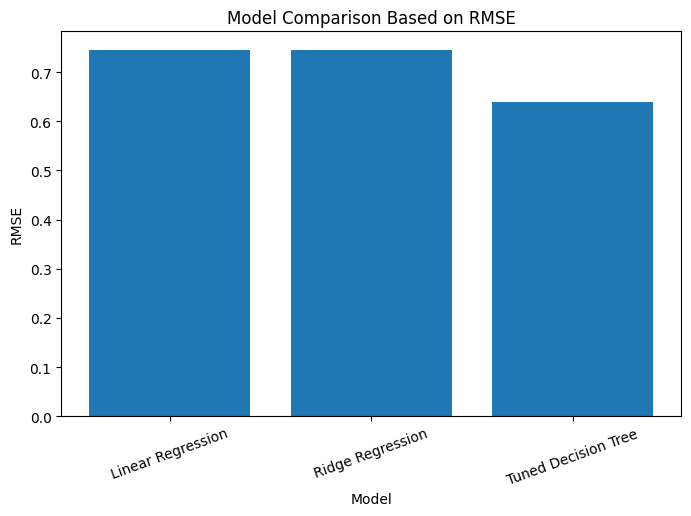

In [13]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xticks(rotation=20)
plt.show()

The final selected model is the Tuned Decision Tree Regressor.

This model was selected because it was optimized using GridSearchCV and evaluated using cross-validation.
The original Decision Tree showed overfitting because it performed extremely well on training data but had weaker testing performance.

Overfitting was reduced by tuning hyperparameters such as max_depth, min_samples_split, and min_samples_leaf.
These parameters control the complexity of the tree and prevent it from learning unnecessary noise from the training data.

Cross-validation results are trusted because the model is tested on multiple different data splits instead of only one train-test split.
This gives a more reliable estimate of model performance.

Linear Regression and Ridge Regression are simpler models, but they may not capture complex relationships in the California Housing Dataset.
The Tuned Decision Tree gives a better balance between performance and generalization.

Therefore, the Tuned Decision Tree is selected as the final optimized model.